<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/main/nifty50_monthly_eda_prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [5]:
nifty_df = pd.read_csv('nifty50_25years_ohlcv_1999_2026.csv')

In [6]:
nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6286 entries, 0 to 6285
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6286 non-null   object 
 1   Open    6286 non-null   float64
 2   High    6286 non-null   float64
 3   Low     6286 non-null   float64
 4   Close   6286 non-null   float64
 5   Volume  6286 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 294.8+ KB


* Aggreggating it to monthly data

In [7]:
nifty_df = pd.read_csv('nifty50_25years_ohlcv_1999_2026.csv', parse_dates=['Date'])

In [8]:
df = pd.read_csv('nifty50_25years_ohlcv_1999_2026.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

monthly = df.resample('MS').agg(
    Month_Open  = ('Open',  'first'),
    Month_Close = ('Close', 'last'),
    Month_High  = ('High',  'max'),
    Month_Low   = ('Low',   'min'),
    Avg_Volume  = ('Volume','mean')
).reset_index()

monthly.rename(columns={'Date': 'Month'}, inplace=True)

# Check which months are missing
print(monthly[monthly['Month_Close'].isnull()][['Month']])

# Drop missing months
monthly.dropna(inplace=True)
print(monthly.shape)
print(monthly.dtypes)

         Month
49  2003-02-01
50  2003-03-01
51  2003-04-01
52  2003-05-01
53  2003-06-01
54  2003-07-01
55  2003-08-01
56  2003-09-01
57  2003-10-01
58  2003-11-01
59  2003-12-01
96  2007-01-01
97  2007-02-01
98  2007-03-01
99  2007-04-01
100 2007-05-01
101 2007-06-01
102 2007-07-01
103 2007-08-01
(308, 6)
Month          datetime64[ns]
Month_Open            float64
Month_Close           float64
Month_High            float64
Month_Low             float64
Avg_Volume            float64
dtype: object


In [9]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 326
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        308 non-null    datetime64[ns]
 1   Month_Open   308 non-null    float64       
 2   Month_Close  308 non-null    float64       
 3   Month_High   308 non-null    float64       
 4   Month_Low    308 non-null    float64       
 5   Avg_Volume   308 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 16.8 KB


*checking for stationarity*

*feature engineering*

In [10]:
monthly['Monthly_Return_%']  = (monthly['Month_Close'] - monthly['Month_Open']) / monthly['Month_Open'] * 100
monthly['HL_Range_%']        = (monthly['Month_High']  - monthly['Month_Low'])   / monthly['Month_Open'] * 100
monthly['Body_Ratio']        = abs(monthly['Month_Close'] - monthly['Month_Open']) / (monthly['Month_High'] - monthly['Month_Low'])
monthly['Upper_Shadow_%']    = (monthly['Month_High'] - monthly[['Month_Open','Month_Close']].max(axis=1)) / monthly['Month_Open'] * 100
monthly['Lower_Shadow_%']    = (monthly[['Month_Open','Month_Close']].min(axis=1) - monthly['Month_Low'])  / monthly['Month_Open'] * 100
monthly['Recovery_Rate_%'] = (monthly['Month_Close'] - monthly['Month_Low']) / (monthly['Month_High'] - monthly['Month_Low']) * 100

In [11]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 326
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Month             308 non-null    datetime64[ns]
 1   Month_Open        308 non-null    float64       
 2   Month_Close       308 non-null    float64       
 3   Month_High        308 non-null    float64       
 4   Month_Low         308 non-null    float64       
 5   Avg_Volume        308 non-null    float64       
 6   Monthly_Return_%  308 non-null    float64       
 7   HL_Range_%        308 non-null    float64       
 8   Body_Ratio        308 non-null    float64       
 9   Upper_Shadow_%    308 non-null    float64       
 10  Lower_Shadow_%    308 non-null    float64       
 11  Recovery_Rate_%   308 non-null    float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 31.3 KB


In [12]:
# Target variable
monthly['Next_Month_Return_%'] = monthly['Monthly_Return_%'].shift(-1)
monthly['Next_Month_Direction'] = (monthly['Next_Month_Return_%'] > 0).astype(int)

# Drop last row (NaN target after shift)
monthly = monthly.dropna(subset=['Next_Month_Return_%'])

print(monthly[['Month', 'Monthly_Return_%', 'Next_Month_Return_%', 'Next_Month_Direction']].tail())
print(f"\nShape: {monthly.shape}")
print(f"Direction balance: {monthly['Next_Month_Direction'].value_counts().to_dict()}")

         Month  Monthly_Return_%  Next_Month_Return_%  Next_Month_Direction
321 2025-10-01          4.474103             1.969501                     1
322 2025-11-01          1.969501            -0.745281                     0
323 2025-12-01         -0.745281            -3.257711                     0
324 2026-01-01         -3.257711             1.541146                     1
325 2026-02-01          1.541146             0.837208                     1

Shape: (307, 14)
Direction balance: {1: 176, 0: 131}


In [13]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307 entries, 0 to 325
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 307 non-null    datetime64[ns]
 1   Month_Open            307 non-null    float64       
 2   Month_Close           307 non-null    float64       
 3   Month_High            307 non-null    float64       
 4   Month_Low             307 non-null    float64       
 5   Avg_Volume            307 non-null    float64       
 6   Monthly_Return_%      307 non-null    float64       
 7   HL_Range_%            307 non-null    float64       
 8   Body_Ratio            307 non-null    float64       
 9   Upper_Shadow_%        307 non-null    float64       
 10  Lower_Shadow_%        307 non-null    float64       
 11  Recovery_Rate_%       307 non-null    float64       
 12  Next_Month_Return_%   307 non-null    float64       
 13  Next_Month_Direction  307

*plotting monthly opening and closing prices*

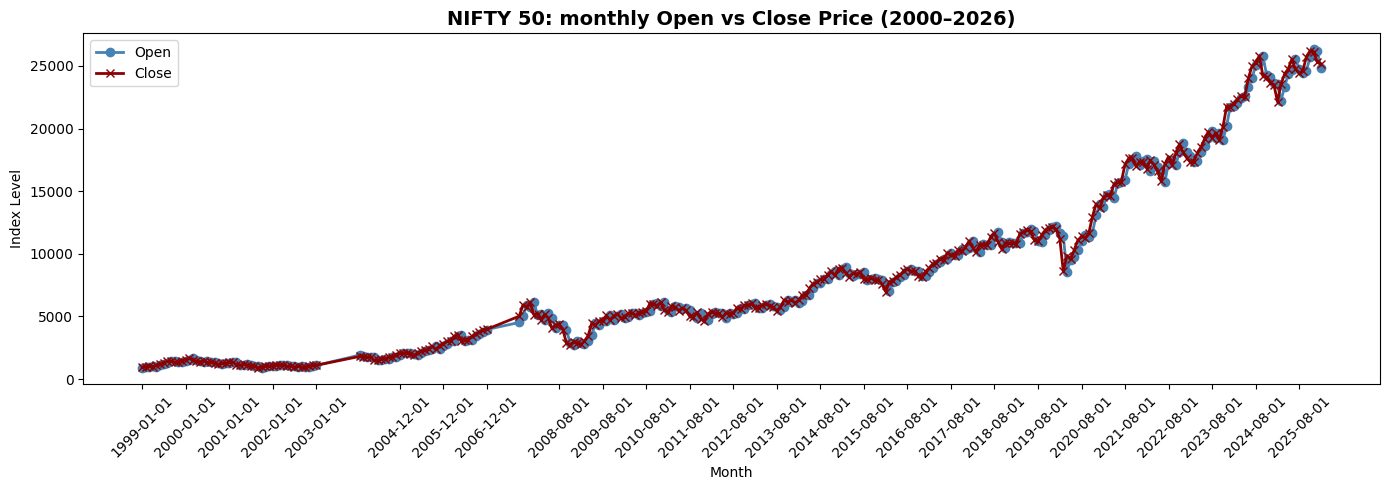

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(monthly['Month'], monthly['Month_Open'],  label='Open',  marker='o', color='steelblue', linewidth=2)
plt.plot(monthly['Month'], monthly['Month_Close'], label='Close', marker='x', color='darkred',   linewidth=2)

plt.title('NIFTY 50: monthly Open vs Close Price (2000–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Index Level')
plt.xticks(monthly['Month'][::12], rotation=45)  # one tick per year
plt.legend()
plt.tight_layout()
plt.show()

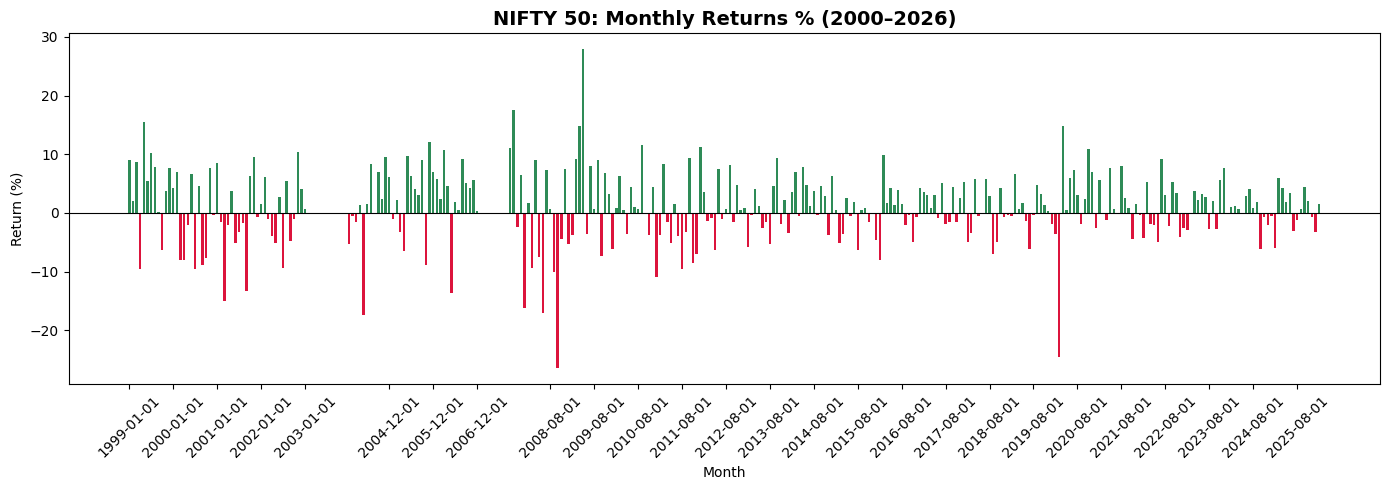

In [15]:
plt.figure(figsize=(14, 5))
plt.bar(monthly['Month'], monthly['Monthly_Return_%'],
        color=monthly['Monthly_Return_%'].apply(lambda x: 'seagreen' if x > 0 else 'crimson'),
        width=20)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('NIFTY 50: Monthly Returns % (2000–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Return (%)')
plt.xticks(monthly['Month'][::12], rotation=45)
plt.tight_layout()
plt.show()

*feature engineering of previous bull return % and previous bear return %

In [16]:
monthly['Bull_Return_%'] = monthly['Monthly_Return_%'].clip(lower=0)  # green months only, 0 for red
monthly['Bear_Return_%'] = monthly['Monthly_Return_%'].clip(upper=0)  # red months only, 0 for green


monthly['Prev_Bull_Return_%'] = monthly['Bull_Return_%'].shift(1)
monthly['Prev_Bear_Return_%'] = monthly['Bear_Return_%'].shift(1)

In [17]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307 entries, 0 to 325
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 307 non-null    datetime64[ns]
 1   Month_Open            307 non-null    float64       
 2   Month_Close           307 non-null    float64       
 3   Month_High            307 non-null    float64       
 4   Month_Low             307 non-null    float64       
 5   Avg_Volume            307 non-null    float64       
 6   Monthly_Return_%      307 non-null    float64       
 7   HL_Range_%            307 non-null    float64       
 8   Body_Ratio            307 non-null    float64       
 9   Upper_Shadow_%        307 non-null    float64       
 10  Lower_Shadow_%        307 non-null    float64       
 11  Recovery_Rate_%       307 non-null    float64       
 12  Next_Month_Return_%   307 non-null    float64       
 13  Next_Month_Direction  307

In [18]:
monthly = monthly.dropna(subset=['Prev_Bull_Return_%', 'Prev_Bear_Return_%'])
print(monthly.shape)  # should be (306, 18)

(306, 18)


In [19]:
monthly['Rolling_CAGR_%'] = (
    monthly['Month_Close']
    .pct_change(12)  # 12-month rolling return
    * 100
)

monthly = monthly.dropna(subset=['Rolling_CAGR_%'])
print(monthly.shape)

(294, 19)


In [20]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 13 to 325
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Month                 294 non-null    datetime64[ns]
 1   Month_Open            294 non-null    float64       
 2   Month_Close           294 non-null    float64       
 3   Month_High            294 non-null    float64       
 4   Month_Low             294 non-null    float64       
 5   Avg_Volume            294 non-null    float64       
 6   Monthly_Return_%      294 non-null    float64       
 7   HL_Range_%            294 non-null    float64       
 8   Body_Ratio            294 non-null    float64       
 9   Upper_Shadow_%        294 non-null    float64       
 10  Lower_Shadow_%        294 non-null    float64       
 11  Recovery_Rate_%       294 non-null    float64       
 12  Next_Month_Return_%   294 non-null    float64       
 13  Next_Month_Direction  29

*baseline feature*

In [24]:


feature_cols = [
    'Monthly_Return_%', 'HL_Range_%', 'Body_Ratio',
    'Upper_Shadow_%', 'Lower_Shadow_%', 'Recovery_Rate_%',
    'Avg_Volume', 'Prev_Bull_Return_%', 'Prev_Bear_Return_%',
    'Rolling_CAGR_%'
]

X = monthly[feature_cols]
y_reg = monthly['Next_Month_Return_%']
y_clf = monthly['Next_Month_Direction']

split = int(len(monthly) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_reg_train, y_reg_test = y_reg.iloc[:split], y_reg.iloc[split:]
y_clf_train, y_clf_test = y_clf.iloc[:split], y_clf.iloc[split:]



**Regression models using Random Forest, XGBoost**

In [25]:
models_reg = {
    'Ridge':         Ridge(),
    'RandomForest':  RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':       XGBRegressor(n_estimators=100, random_state=42)
}



**Classification models using Logistic regression, Random forest, XGBoost**

In [26]:
models_clf = {
    'LogisticReg':   LogisticRegression(),
    'RandomForest':  RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':       XGBClassifier(n_estimators=100, random_state=42)
}



**Summary of models**

In [27]:
print("=== REGRESSION ===")
for name, model in models_reg.items():
    model.fit(X_train, y_reg_train)
    pred = model.predict(X_test)
    print(f"{name:15} MAE: {mean_absolute_error(y_reg_test, pred):.3f}  RMSE: {root_mean_squared_error(y_reg_test, pred):.3f}")

print("\n=== CLASSIFICATION ===")
for name, model in models_clf.items():
    model.fit(X_train, y_clf_train)
    pred = model.predict(X_test)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf_test, pred):.3f}  F1: {f1_score(y_clf_test, pred):.3f}")

=== REGRESSION ===
Ridge           MAE: 3.022  RMSE: 3.714


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.26728e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


RandomForest    MAE: 3.194  RMSE: 4.127
XGBoost         MAE: 3.864  RMSE: 4.831

=== CLASSIFICATION ===
LogisticReg     Accuracy: 0.593  F1: 0.745
RandomForest    Accuracy: 0.610  F1: 0.657
XGBoost         Accuracy: 0.644  F1: 0.712


* Ridge has the lowest MAE and RMSE

* Accuracy is higher for XGBoost followed by Random forest

* It is worth noticing that F1 score is most higher for Logistic regression.


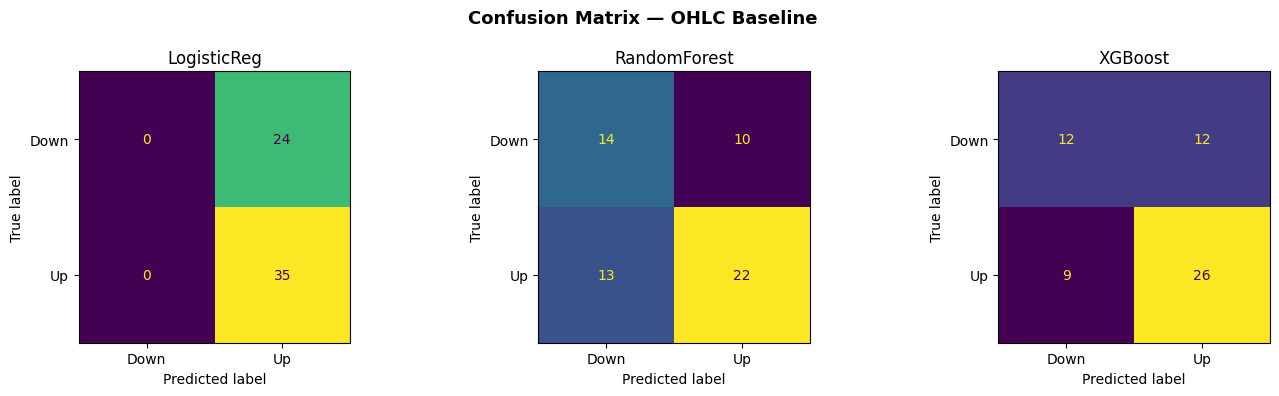

In [28]:


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models_clf.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_clf_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrix — OHLC Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Overall false pedictions only differ by one.
* logistic regression ; false prediction 24,
* random forest 23 and xgboost 22.
* so xgboost is better
* Logistic regression only provides up details